# Parameter Calibration: Synthetic Benchmark and Real BOAMP Diagnostics

This notebook calibrates broad, balanced, and strict proxy-event definitions by combining:

- controlled synthetic BOAMP benchmark reliability, where synthetic true links are known by construction;
- current real BOAMP candidate-pair diagnostics, where no certified recurrence-chain labels exist;
- available negative-control evidence from runner-up candidates and robustness outputs.

Important interpretation: real BOAMP `event = 1` means a proxy recurrence, i.e. an identifiable reappearance of a similar procurement need under the matching rule. It is not a formally certified recurrence chain.


## 0. Setup

The notebook uses only files found in the current repository. It stops with a clear error if a required input or required column is missing.


In [1]:
from __future__ import annotations

import math
import os
import re
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

_cwd = Path.cwd()
PROJ = _cwd
for candidate in [_cwd, *_cwd.parents]:
    if (candidate / "data").exists() and (candidate / "notebooks").exists():
        PROJ = candidate
        break
os.chdir(PROJ)

DATA = PROJ / "data"
SYNTHETIC = DATA / "synthetic"
REPORT_TABLES = PROJ / "reports" / "tables" / "validation"
REPORT_FIGURES = PROJ / "reports" / "figures" / "validation"
REAL_OUT = PROJ / "boamp_renewal_linking_quality" / "outputs"
ROBUSTNESS_OUT = PROJ / "validation_robustness" / "outputs"
EVENT_VALIDATION_OUT = PROJ / "event_validation" / "outputs"
NOTEBOOK_PATH = PROJ / "notebooks" / "05_parameter_calibration_benchmark_and_real.ipynb"

REPORT_TABLES.mkdir(parents=True, exist_ok=True)
REPORT_FIGURES.mkdir(parents=True, exist_ok=True)

ACADEMIC_PALETTE = ["#1b4d89", "#b85c38", "#2f6f4e", "#7a5195", "#5c677d", "#8a6f3f"]
sns.set_theme(context="paper", style="ticks", palette=ACADEMIC_PALETTE, font="serif")
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "#222222",
    "axes.facecolor": "white",
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.fontsize": 8,
    "legend.frameon": False,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "grid.color": "#d9d9d9",
    "grid.linewidth": 0.45,
    "grid.alpha": 0.7,
})

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

print(f"Project root: {PROJ}")


Project root: /home/senghakrou/stage-1


## 1. Locate and Load Current Inputs

The table below records the exact current paths used by this calibration notebook.


In [2]:
PATHS = {
    "synthetic_notices": SYNTHETIC / "synthetic_boamp_notices_all.csv",
    "synthetic_true_links": SYNTHETIC / "synthetic_boamp_true_links_all.csv",
    "synthetic_threshold_grid": REPORT_TABLES / "synthetic_threshold_grid.csv",
    "real_boamp_candidates": REAL_OUT / "boamp_renewal_candidates.csv",
    "real_boamp_links": REAL_OUT / "boamp_renewal_links.csv",
    "negative_control_placebo_summary": ROBUSTNESS_OUT / "placebo_check_summary.csv",
    "score_margin_diagnostics": ROBUSTNESS_OUT / "score_margin_diagnostics.csv",
    "manual_validation_metrics": EVENT_VALIDATION_OUT / "manual_validation_metrics.csv",
    "manual_validation_labels": EVENT_VALIDATION_OUT / "manual_validation_audit_labeled.csv",
}

required_inputs = [
    "synthetic_notices",
    "synthetic_true_links",
    "synthetic_threshold_grid",
    "real_boamp_candidates",
    "real_boamp_links",
]

missing = [name for name in required_inputs if not PATHS[name].exists()]
if missing:
    raise SystemExit("Missing required calibration input(s): " + ", ".join(f"{m} -> {PATHS[m]}" for m in missing))

loaded = {}
for name, path in PATHS.items():
    exists = path.exists()
    if exists and path.suffix.lower() == ".csv":
        loaded[name] = pd.read_csv(path, low_memory=False)

input_inventory = []
for name, path in PATHS.items():
    df = loaded.get(name)
    input_inventory.append({
        "input_name": name,
        "file_path": str(path.relative_to(PROJ)),
        "exists": path.exists(),
        "rows": len(df) if df is not None else np.nan,
        "columns": len(df.columns) if df is not None else np.nan,
        "used_for": {
            "synthetic_notices": "synthetic ID and scenario integrity checks",
            "synthetic_true_links": "synthetic true-link integrity checks",
            "synthetic_threshold_grid": "synthetic precision/recall/F1 by rule",
            "real_boamp_candidates": "real BOAMP rule diagnostics and negative controls",
            "real_boamp_links": "eligible real BOAMP denominator for linking rates",
            "negative_control_placebo_summary": "external placebo/runner-up context",
            "score_margin_diagnostics": "external score-margin context",
            "manual_validation_metrics": "manual validation context, not used as full ground truth",
            "manual_validation_labels": "manual audit context, not used as full ground truth",
        }.get(name, "context"),
    })
input_inventory = pd.DataFrame(input_inventory)
input_inventory.to_csv(REPORT_TABLES / "parameter_calibration_input_inventory.csv", index=False)
display(input_inventory)

notices = loaded["synthetic_notices"]
truth = loaded["synthetic_true_links"]
synthetic_grid = loaded["synthetic_threshold_grid"]
real_candidates = loaded["real_boamp_candidates"]
real_links = loaded["real_boamp_links"]
placebo_summary = loaded.get("negative_control_placebo_summary", pd.DataFrame())


,input_name,file_path,exists,rows,columns,used_for
0,synthetic_notices,data/synthetic/synthetic_boamp_notices_all.csv,True,11326,19,synthetic ID and scenario integrity checks
1,synthetic_true_links,data/synthetic/synthetic_boamp_true_links_all.csv,True,4500,5,synthetic true-link integrity checks
2,synthetic_threshold_grid,reports/tables/validation/synthetic_threshold_grid.csv,True,4320,23,synthetic precision/recall/F1 by rule
3,real_boamp_candidates,boamp_renewal_linking_quality/outputs/boamp_renewal_candidates.csv,True,3201,17,real BOAMP rule diagnostics and negative controls
4,real_boamp_links,boamp_renewal_linking_quality/outputs/boamp_renewal_links.csv,True,1210,30,eligible real BOAMP denominator for linking rates
5,negative_control_placebo_summary,validation_robustness/outputs/placebo_check_summary.csv,True,3,7,external placebo/runner-up context
6,score_margin_diagnostics,validation_robustness/outputs/score_margin_diagnostics.csv,True,5,9,external score-margin context
7,manual_validation_metrics,event_validation/outputs/manual_validation_metrics.csv,True,31,2,"manual validation context, not used as full ground truth"
8,manual_validation_labels,event_validation/outputs/manual_validation_audit_labeled.csv,True,150,33,"manual audit context, not used as full ground truth"


## 2. Input Verification

These checks prevent silent calibration on stale or incompatible files.


In [3]:
def require_columns(df: pd.DataFrame, cols: list[str], name: str):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise SystemExit(f"{name} is missing required columns: {missing}")

require_columns(notices, [
    "notice_id", "scenario", "role", "buyer_key", "object", "cpv",
    "start_date", "declared_duration_months", "estimated_end_date",
], "synthetic notices")
require_columns(truth, ["source_id", "true_candidate_id", "true_event", "scenario"], "synthetic true links")
require_columns(synthetic_grid, [
    "scenario", "text_threshold", "composite_threshold", "margin_threshold", "W", "generic_cpv_rule",
    "precision", "recall", "F1", "linking_rate", "TP", "FP", "FN", "TN",
    "median_text_similarity", "median_composite_score", "median_margin", "share_generic_cpv_links",
], "synthetic threshold grid")
require_columns(real_candidates, [
    "src_idweb", "cand_idweb", "src_cpv", "cand_cpv", "src_duration_months", "gap_months",
    "text_similarity_score", "temporal_proximity_score", "composite_score",
], "real BOAMP candidate pairs")
require_columns(real_links, ["contract_id", "event"], "real BOAMP links")

required_scenarios = {"easy", "medium", "hard"}
scenario_set_grid = set(synthetic_grid["scenario"].astype(str))
scenario_set_notices = set(notices["scenario"].astype(str))
scenario_set_truth = set(truth["scenario"].astype(str))
if scenario_set_grid != required_scenarios:
    raise SystemExit(f"Synthetic grid scenario mismatch: {scenario_set_grid}")
if not required_scenarios.issubset(scenario_set_notices):
    raise SystemExit(f"Synthetic notices missing scenarios: {required_scenarios - scenario_set_notices}")
if not required_scenarios.issubset(scenario_set_truth):
    raise SystemExit(f"Synthetic truth missing scenarios: {required_scenarios - scenario_set_truth}")

notice_ids = set(notices["notice_id"].astype(str))
source_ids = set(notices.loc[notices["role"].eq("source"), "notice_id"].astype(str))
truth_source_ok = set(truth["source_id"].astype(str)).issubset(source_ids)
true_cands = truth.loc[truth["true_event"].eq(1), "true_candidate_id"].dropna().astype(str)
truth_candidate_ok = set(true_cands).issubset(notice_ids)
if not truth_source_ok:
    raise SystemExit("Some synthetic true-link source_id values are absent from synthetic notices.")
if not truth_candidate_ok:
    raise SystemExit("Some synthetic true_candidate_id values are absent from synthetic notices.")

score_cols = ["text_similarity_score", "composite_score", "gap_months", "src_duration_months"]
critical_missing = real_candidates[score_cols].isna().mean().to_dict()
if real_candidates["text_similarity_score"].isna().any() or real_candidates["composite_score"].isna().any():
    raise SystemExit("Real candidate table has missing critical text/composite scores.")

verification = pd.DataFrame([
    {"check": "synthetic notices rows", "value": len(notices), "status": "PASS"},
    {"check": "synthetic truth rows", "value": len(truth), "status": "PASS"},
    {"check": "synthetic grid rows", "value": len(synthetic_grid), "status": "PASS"},
    {"check": "real candidate-pair rows", "value": len(real_candidates), "status": "PASS"},
    {"check": "real eligible link rows", "value": len(real_links), "status": "PASS"},
    {"check": "scenarios easy/medium/hard", "value": ",".join(sorted(required_scenarios)), "status": "PASS"},
    {"check": "true-link candidate IDs exist", "value": truth_candidate_ok, "status": "PASS"},
    {"check": "true-link source IDs exist", "value": truth_source_ok, "status": "PASS"},
    {"check": "critical score missing rates", "value": str(critical_missing), "status": "PASS"},
])
verification.to_csv(REPORT_TABLES / "parameter_calibration_input_checks.csv", index=False)
display(verification)


,check,value,status
0,synthetic notices rows,11326,PASS
1,synthetic truth rows,4500,PASS
2,synthetic grid rows,4320,PASS
3,real candidate-pair rows,3201,PASS
4,real eligible link rows,1210,PASS
5,scenarios easy/medium/hard,"easy,hard,medium",PASS
6,true-link candidate IDs exist,True,PASS
7,true-link source IDs exist,True,PASS
8,critical score missing rates,"{'text_similarity_score': 0.0, 'composite_score': 0.0, 'gap_months': 0.0, 'src_duration_months': 0.0}",PASS


## 3. Calibration Helpers

The real BOAMP candidate table is the current project candidate pool. It was generated by the current linker with a W=6 temporal candidate pool. Rules with W=9 or W=12 are therefore computed as lower-bound diagnostics from the existing candidate pool, not as a full wider-window real rerun.

The available negative control is the set of runner-up/non-winning candidates from the real candidate table. A low runner-up pass rate means the rule is less likely to admit ambiguous non-winning candidates.


In [4]:
GENERIC_CPV_CODES = {"72000000", "48000000", "32000000", "35000000"}

def clean_cpv(value):
    if pd.isna(value):
        return None
    text = re.sub(r"\.0$", "", str(value).strip())
    digits = re.sub(r"\D", "", text)
    if len(digits) < 2:
        return None
    return digits[:8].zfill(8)

def cpv_score(src_cpv, cand_cpv, generic_rule: str):
    src = clean_cpv(src_cpv)
    cand = clean_cpv(cand_cpv)
    if src is None or cand is None:
        return np.nan
    same_div = src[:2] == cand[:2]
    src_generic = src in GENERIC_CPV_CODES or src.endswith("000000")
    cand_generic = cand in GENERIC_CPV_CODES or cand.endswith("000000")

    if generic_rule == "generic_exact_credit" and src[:8] == cand[:8]:
        return 1.0
    if src_generic or cand_generic:
        return 0.20 if same_div else 0.0
    if src[:8] == cand[:8]:
        return 1.00
    if src[:5] == cand[:5]:
        return 0.80
    if src[:4] == cand[:4]:
        return 0.60
    if src[:3] == cand[:3]:
        return 0.40
    return 0.20 if same_div else 0.0

def composite_score(text_score, cpv_s, temporal_s, buyer_s=1.0):
    if pd.isna(cpv_s):
        return (0.40 * text_score + 0.20 * temporal_s + 0.15 * buyer_s) / 0.75
    return 0.40 * text_score + 0.25 * cpv_s + 0.20 * temporal_s + 0.15 * buyer_s

def normalize_threshold(value):
    if pd.isna(value) or str(value) == "none":
        return "none"
    return float(value)

def prepare_real_pairs(W: int, generic_rule: str) -> pd.DataFrame:
    pairs = real_candidates.copy()
    pairs["text_score_rule"] = pd.to_numeric(pairs["text_similarity_score"], errors="coerce")
    pairs["gap_months_rule"] = pd.to_numeric(pairs["gap_months"], errors="coerce")
    pairs["duration_rule"] = pd.to_numeric(pairs["src_duration_months"], errors="coerce").fillna(48.0)
    deviation = (pairs["gap_months_rule"] - pairs["duration_rule"]).abs()
    pairs["temporal_score_rule"] = (1.0 - deviation / float(W)).clip(lower=0.0, upper=1.0)
    pairs["cpv_score_rule"] = [cpv_score(s, c, generic_rule) for s, c in zip(pairs["src_cpv"], pairs["cand_cpv"])]
    pairs["composite_score_rule"] = [
        composite_score(t, c, ts)
        for t, c, ts in zip(pairs["text_score_rule"], pairs["cpv_score_rule"], pairs["temporal_score_rule"])
    ]
    pairs["source_generic_cpv"] = pairs["src_cpv"].map(lambda x: clean_cpv(x) in GENERIC_CPV_CODES if clean_cpv(x) else False)
    pairs["candidate_generic_cpv"] = pairs["cand_cpv"].map(lambda x: clean_cpv(x) in GENERIC_CPV_CODES if clean_cpv(x) else False)
    return pairs

def apply_rule_to_real(text_threshold, composite_threshold, margin_threshold, W, generic_rule) -> dict:
    composite_threshold = normalize_threshold(composite_threshold)
    margin_threshold = normalize_threshold(margin_threshold)
    pairs = prepare_real_pairs(int(W), str(generic_rule))

    ranked_all = pairs.sort_values(
        ["src_idweb", "composite_score_rule", "text_score_rule", "gap_months_rule"],
        ascending=[True, False, False, True],
    ).copy()
    ranked_all["rank_all"] = ranked_all.groupby("src_idweb").cumcount() + 1
    runner_up = ranked_all[ranked_all["rank_all"] >= 2].copy()
    if len(runner_up):
        runner_pass = runner_up["text_score_rule"] >= float(text_threshold)
        if composite_threshold != "none":
            runner_pass &= runner_up["composite_score_rule"] >= float(composite_threshold)
        negative_control_pass_rate = float(runner_pass.mean())
        negative_control_pass_count = int(runner_pass.sum())
        negative_control_n = int(len(runner_up))
    else:
        negative_control_pass_rate = 0.0
        negative_control_pass_count = 0
        negative_control_n = 0

    filtered = pairs[pairs["text_score_rule"] >= float(text_threshold)].copy()
    if composite_threshold != "none":
        filtered = filtered[filtered["composite_score_rule"] >= float(composite_threshold)].copy()

    if filtered.empty:
        event_count = 0
        return {
            "real_event_count": 0,
            "real_linking_rate": 0.0,
            "events_available_for_survival": 0,
            "negative_control_pass_rate": negative_control_pass_rate,
            "negative_control_pass_count": negative_control_pass_count,
            "negative_control_n": negative_control_n,
            "real_median_text_similarity": np.nan,
            "real_median_composite_score": np.nan,
            "real_median_margin": np.nan,
            "real_generic_cpv_share": 0.0,
            "real_candidate_pool_note": "actual current W=6 candidate pool" if int(W) == 6 else "lower-bound diagnostic from current W=6 candidate pool",
        }

    filtered = filtered.sort_values(
        ["src_idweb", "composite_score_rule", "text_score_rule", "gap_months_rule"],
        ascending=[True, False, False, True],
    ).copy()
    filtered["rank"] = filtered.groupby("src_idweb").cumcount() + 1
    best = filtered[filtered["rank"] == 1].copy()
    second = filtered[filtered["rank"] == 2][["src_idweb", "composite_score_rule"]].rename(
        columns={"composite_score_rule": "second_best_score_rule"}
    )
    best = best.merge(second, on="src_idweb", how="left")
    best["score_margin_rule"] = best["composite_score_rule"] - best["second_best_score_rule"]

    if margin_threshold != "none":
        best = best[best["score_margin_rule"].fillna(-1) >= float(margin_threshold)].copy()

    event_count = int(len(best))
    real_denominator = int(len(real_links))
    generic_share = (
        (best["source_generic_cpv"].fillna(False) | best["candidate_generic_cpv"].fillna(False)).mean()
        if event_count else 0.0
    )
    return {
        "real_event_count": event_count,
        "real_linking_rate": event_count / real_denominator if real_denominator else 0.0,
        "events_available_for_survival": event_count,
        "negative_control_pass_rate": negative_control_pass_rate,
        "negative_control_pass_count": negative_control_pass_count,
        "negative_control_n": negative_control_n,
        "real_median_text_similarity": float(best["text_score_rule"].median()) if event_count else np.nan,
        "real_median_composite_score": float(best["composite_score_rule"].median()) if event_count else np.nan,
        "real_median_margin": float(best["score_margin_rule"].median()) if best["score_margin_rule"].notna().any() else np.nan,
        "real_generic_cpv_share": float(generic_share) if event_count else 0.0,
        "real_candidate_pool_note": "actual current W=6 candidate pool" if int(W) == 6 else "lower-bound diagnostic from current W=6 candidate pool",
    }


## 4. Combine Synthetic Reliability and Real Diagnostics

The synthetic grid is reused from notebook 04 because it already contains the requested threshold combinations. Real diagnostics are recomputed here from the current BOAMP candidate-pair table for each rule.


In [5]:
rule_cols = ["text_threshold", "composite_threshold", "margin_threshold", "W", "generic_cpv_rule"]

wide_synth = synthetic_grid.pivot_table(
    index=rule_cols,
    columns="scenario",
    values=["precision", "recall", "F1", "linking_rate", "TP", "FP", "FN", "TN"],
    aggfunc="first",
)
wide_synth.columns = [f"synthetic_{scenario}_{metric}" for metric, scenario in wide_synth.columns]
wide_synth = wide_synth.reset_index()

real_metric_rows = []
for _, rule in wide_synth[rule_cols].iterrows():
    m = apply_rule_to_real(
        rule["text_threshold"],
        rule["composite_threshold"],
        rule["margin_threshold"],
        rule["W"],
        rule["generic_cpv_rule"],
    )
    real_metric_rows.append({**rule.to_dict(), **m})
real_metrics = pd.DataFrame(real_metric_rows)

calibration = wide_synth.merge(real_metrics, on=rule_cols, how="left")
calibration["generic_cpv_rule_label"] = calibration["generic_cpv_rule"].map({
    "generic_exact_credit": "legacy_exact_credit_counterfactual",
    "generic_corrected": "corrected_current_project",
}).fillna(calibration["generic_cpv_rule"])
calibration["mean_synthetic_F1"] = calibration[["synthetic_easy_F1", "synthetic_medium_F1", "synthetic_hard_F1"]].mean(axis=1)
calibration["medium_hard_F1"] = calibration[["synthetic_medium_F1", "synthetic_hard_F1"]].mean(axis=1)
calibration["medium_hard_precision"] = calibration[["synthetic_medium_precision", "synthetic_hard_precision"]].mean(axis=1)
calibration["medium_hard_recall"] = calibration[["synthetic_medium_recall", "synthetic_hard_recall"]].mean(axis=1)
calibration["reliability_score"] = (
    0.40 * calibration["medium_hard_F1"] +
    0.25 * calibration["medium_hard_precision"] +
    0.20 * calibration["medium_hard_recall"] +
    0.15 * (1.0 - calibration["negative_control_pass_rate"].clip(0, 1))
)

calibration.to_csv(REPORT_TABLES / "parameter_calibration_results.csv", index=False)
print(f"Saved {len(calibration):,} rows -> {REPORT_TABLES / 'parameter_calibration_results.csv'}")
display(calibration.head())


Saved 1,440 rows -> /home/senghakrou/stage-1/reports/tables/validation/parameter_calibration_results.csv


,text_threshold,composite_threshold,margin_threshold,W,generic_cpv_rule,synthetic_easy_F1,synthetic_hard_F1,synthetic_medium_F1,synthetic_easy_FN,synthetic_hard_FN,synthetic_medium_FN,synthetic_easy_FP,synthetic_hard_FP,synthetic_medium_FP,synthetic_easy_TN,synthetic_hard_TN,synthetic_medium_TN,synthetic_easy_TP,synthetic_hard_TP,synthetic_medium_TP,synthetic_easy_linking_rate,synthetic_hard_linking_rate,synthetic_medium_linking_rate,synthetic_easy_precision,synthetic_hard_precision,synthetic_medium_precision,synthetic_easy_recall,synthetic_hard_recall,synthetic_medium_recall,real_event_count,real_linking_rate,events_available_for_survival,negative_control_pass_rate,negative_control_pass_count,negative_control_n,real_median_text_similarity,real_median_composite_score,real_median_margin,real_generic_cpv_share,real_candidate_pool_note,generic_cpv_rule_label,mean_synthetic_F1,medium_hard_F1,medium_hard_precision,medium_hard_recall,reliability_score
0,0.4,0.5,0.05,6,generic_corrected,0.295760,0.161736,0.279762,624,653,617,57,197,109,690,654,669,143,82,141,0.133333,0.186000,0.166667,0.715000,0.293907,0.564000,0.186441,0.111565,0.186016,70,0.057851,70,0.149054,378,2536,0.69565,0.688580,0.110807,0.171429,actual current W=6 candidate pool,corrected_current_project,0.245753,0.220749,0.428953,0.148790,0.352938
1,0.4,0.5,0.05,6,generic_exact_credit,0.298969,0.171206,0.290227,622,647,611,58,205,108,689,650,669,145,88,147,0.135333,0.195333,0.170000,0.714286,0.300341,0.576471,0.189048,0.119728,0.193931,78,0.064463,78,0.160095,406,2536,0.66720,0.711740,0.113680,0.256410,actual current W=6 candidate pool,legacy_exact_credit_counterfactual,0.253467,0.230717,0.438406,0.156830,0.359240
2,0.4,0.5,0.05,9,generic_corrected,0.337972,0.216758,0.342056,597,616,575,69,244,129,680,622,646,170,119,183,0.159333,0.242000,0.208000,0.711297,0.327824,0.586538,0.221643,0.161905,0.241425,89,0.073554,89,0.212145,538,2536,0.69240,0.707520,0.110978,0.157303,lower-bound diagnostic from current W=6 candidate pool,corrected_current_project,0.298929,0.279407,0.457181,0.201665,0.384569
3,0.4,0.5,0.05,9,generic_exact_credit,0.337637,0.234767,0.354689,597,604,567,70,250,128,679,617,646,170,131,191,0.160000,0.254000,0.212667,0.708333,0.343832,0.598746,0.221643,0.178231,0.251979,96,0.079339,96,0.220426,559,2536,0.67245,0.724342,0.131204,0.218750,lower-bound diagnostic from current W=6 candidate pool,legacy_exact_credit_counterfactual,0.309031,0.294728,0.471289,0.215105,0.395671
4,0.4,0.5,0.05,12,generic_corrected,0.377756,0.246288,0.377224,570,594,546,79,269,154,671,600,627,197,141,212,0.184000,0.273333,0.244000,0.713768,0.343902,0.579235,0.256845,0.191837,0.279683,99,0.081818,99,0.255521,648,2536,0.67520,0.722947,0.119440,0.151515,lower-bound diagnostic from current W=6 candidate pool,corrected_current_project,0.333756,0.311756,0.461569,0.235760,0.398919


## 5. Select Broad, Balanced, and Strict Rules

Selection is computed from the table above, not hard-coded. Because the current real candidate-pair file is a W=6 candidate pool, the selected recommended rules are restricted to W=6 for real BOAMP comparability. Wider-window settings remain visible in the full calibration table but require regenerating real candidate pairs before they can be used as real event definitions.

Constraints used:

- Broad: corrected CPV rule, W=6, medium recall >= 0.38, hard recall >= 0.17, then maximize real linking rate.
- Balanced: corrected CPV rule, W=6, medium precision >= 0.60, medium recall >= 0.30, hard precision >= 0.30, hard recall >= 0.12, runner-up pass rate <= 0.20, at least 150 real events, then maximize real linking rate.
- Strict: corrected CPV rule, W=6, medium precision >= 0.80, hard precision >= 0.40, runner-up pass rate <= 0.01, at least 50 real events, then maximize real linking rate.


In [6]:
current_real_pool = calibration[
    (calibration["generic_cpv_rule"].eq("generic_corrected")) &
    (calibration["W"].eq(6))
].copy()

broad_pool = current_real_pool[
    (current_real_pool["synthetic_medium_recall"] >= 0.38) &
    (current_real_pool["synthetic_hard_recall"] >= 0.17)
].copy()
if broad_pool.empty:
    raise SystemExit("No broad-rule candidate satisfies the configured constraints.")
broad = broad_pool.sort_values(["real_linking_rate", "synthetic_medium_recall", "synthetic_hard_recall"], ascending=False).iloc[0]

balanced_pool = current_real_pool[
    (current_real_pool["synthetic_medium_precision"] >= 0.60) &
    (current_real_pool["synthetic_medium_recall"] >= 0.30) &
    (current_real_pool["synthetic_hard_precision"] >= 0.30) &
    (current_real_pool["synthetic_hard_recall"] >= 0.12) &
    (current_real_pool["negative_control_pass_rate"] <= 0.20) &
    (current_real_pool["real_event_count"] >= 150)
].copy()
if balanced_pool.empty:
    raise SystemExit("No balanced-rule candidate satisfies the configured reliability constraints.")
balanced = balanced_pool.sort_values(["real_linking_rate", "reliability_score"], ascending=False).iloc[0]

strict_pool = current_real_pool[
    (current_real_pool["synthetic_medium_precision"] >= 0.80) &
    (current_real_pool["synthetic_hard_precision"] >= 0.40) &
    (current_real_pool["negative_control_pass_rate"] <= 0.01) &
    (current_real_pool["real_event_count"] >= 50)
].copy()
if strict_pool.empty:
    raise SystemExit("No strict-rule candidate satisfies the configured reliability constraints.")
strict = strict_pool.sort_values(["real_linking_rate", "synthetic_medium_precision", "synthetic_hard_precision"], ascending=False).iloc[0]

selected = []
for rule_name, row, expected_real_use in [
    ("broad", broad, "High recall / high linking-rate proxy-event upper sensitivity."),
    ("balanced", balanced, "Recommended main proxy-event definition for real BOAMP survival rerun."),
    ("strict", strict, "High-precision robustness sensitivity with fewer real events."),
]:
    selected.append({
        "rule_name": rule_name,
        "text_threshold": row["text_threshold"],
        "composite_threshold": row["composite_threshold"],
        "margin_threshold": row["margin_threshold"],
        "W": int(row["W"]),
        "generic_cpv_rule": row["generic_cpv_rule"],
        "real_event_count": int(row["real_event_count"]),
        "real_linking_rate": row["real_linking_rate"],
        "events_available_for_survival": int(row["events_available_for_survival"]),
        "negative_control_pass_rate": row["negative_control_pass_rate"],
        "real_median_text_similarity": row["real_median_text_similarity"],
        "real_median_composite_score": row["real_median_composite_score"],
        "real_median_margin": row["real_median_margin"],
        "real_generic_cpv_share": row["real_generic_cpv_share"],
        "easy_precision": row["synthetic_easy_precision"],
        "easy_recall": row["synthetic_easy_recall"],
        "easy_F1": row["synthetic_easy_F1"],
        "medium_precision": row["synthetic_medium_precision"],
        "medium_recall": row["synthetic_medium_recall"],
        "medium_F1": row["synthetic_medium_F1"],
        "hard_precision": row["synthetic_hard_precision"],
        "hard_recall": row["synthetic_hard_recall"],
        "hard_F1": row["synthetic_hard_F1"],
        "reliability_score": row["reliability_score"],
        "expected_real_use": expected_real_use,
        "selection_basis": "computed from synthetic reliability constraints, runner-up negative-control rate, and actual current real BOAMP linking rate",
    })

recommended = pd.DataFrame(selected)
recommended.to_csv(REPORT_TABLES / "recommended_event_rules.csv", index=False)
display(recommended)


,rule_name,text_threshold,composite_threshold,margin_threshold,W,generic_cpv_rule,real_event_count,real_linking_rate,events_available_for_survival,negative_control_pass_rate,real_median_text_similarity,real_median_composite_score,real_median_margin,real_generic_cpv_share,easy_precision,easy_recall,easy_F1,medium_precision,medium_recall,medium_F1,hard_precision,hard_recall,hard_F1,reliability_score,expected_real_use,selection_basis
0,broad,0.4,none,none,6,generic_corrected,490,0.404959,490,0.416009,0.52985,0.551040,0.055187,0.240816,0.674562,0.853977,0.753740,0.492891,0.686016,0.573635,0.273166,0.385034,0.319593,0.469106,High recall / high linking-rate proxy-event upper sensitivity.,"computed from synthetic reliability constraints, runner-up negative-control rate, and actual current real BOAMP link..."
1,balanced,0.5,0.5,none,6,generic_corrected,269,0.222314,269,0.094243,0.62910,0.624293,0.048160,0.230483,0.777358,0.805737,0.791293,0.600812,0.585752,0.593186,0.317597,0.302041,0.309623,0.520006,Recommended main proxy-event definition for real BOAMP survival rerun.,"computed from synthetic reliability constraints, runner-up negative-control rate, and actual current real BOAMP link..."
2,strict,0.7,0.65,none,6,generic_corrected,79,0.065289,79,0.003549,0.84650,0.806213,0.031880,0.164557,0.885965,0.658409,0.755423,0.801858,0.341689,0.479186,0.447489,0.133333,0.205451,0.490065,High-precision robustness sensitivity with fewer real events.,"computed from synthetic reliability constraints, runner-up negative-control rate, and actual current real BOAMP link..."


## 6. Plots

All plots use the same academic style as the benchmark notebook and are saved to `reports/figures/validation/`.


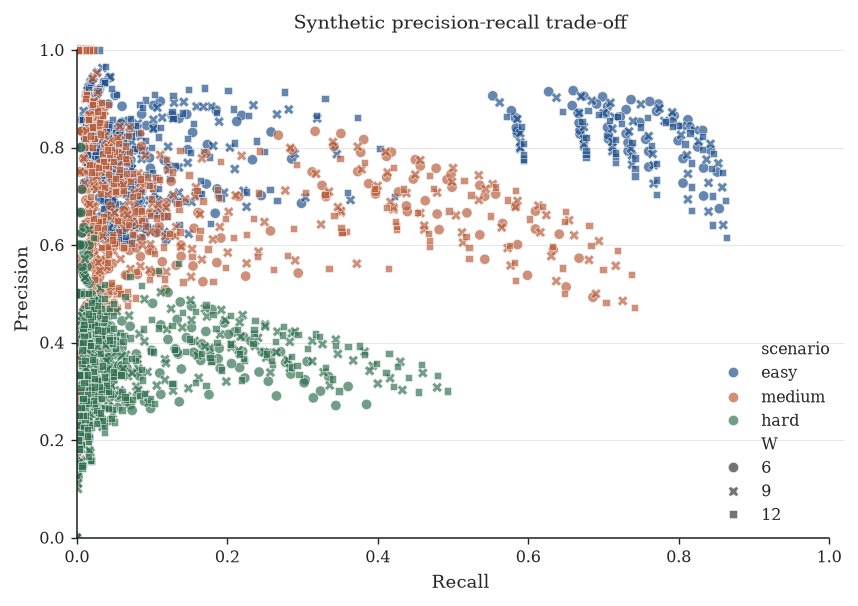

/home/senghakrou/stage-1/reports/figures/validation/parameter_precision_vs_recall.png


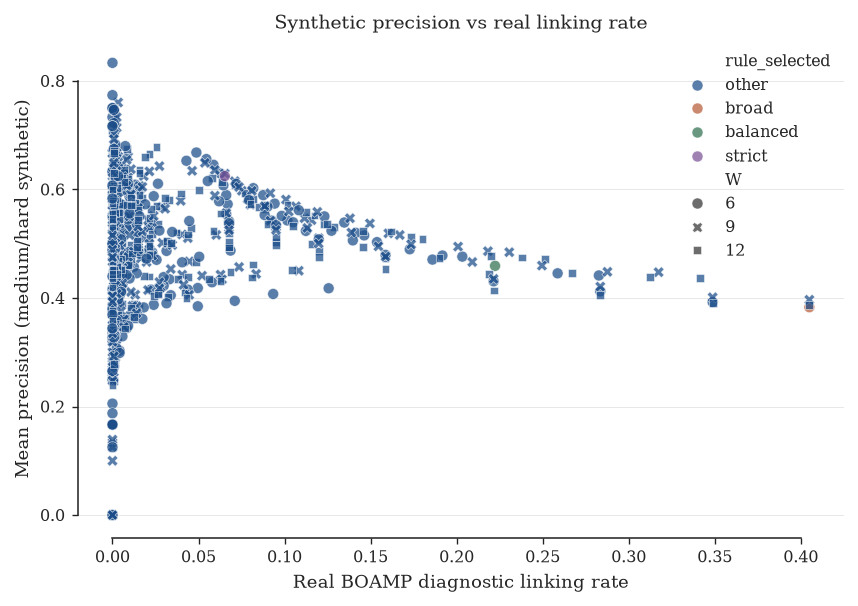

/home/senghakrou/stage-1/reports/figures/validation/parameter_precision_vs_real_linking_rate.png


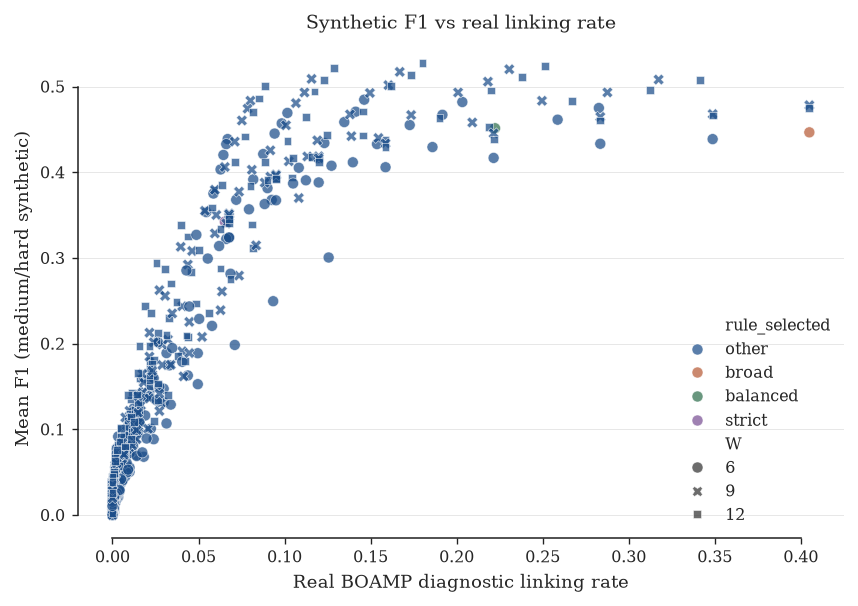

/home/senghakrou/stage-1/reports/figures/validation/parameter_f1_vs_real_linking_rate.png


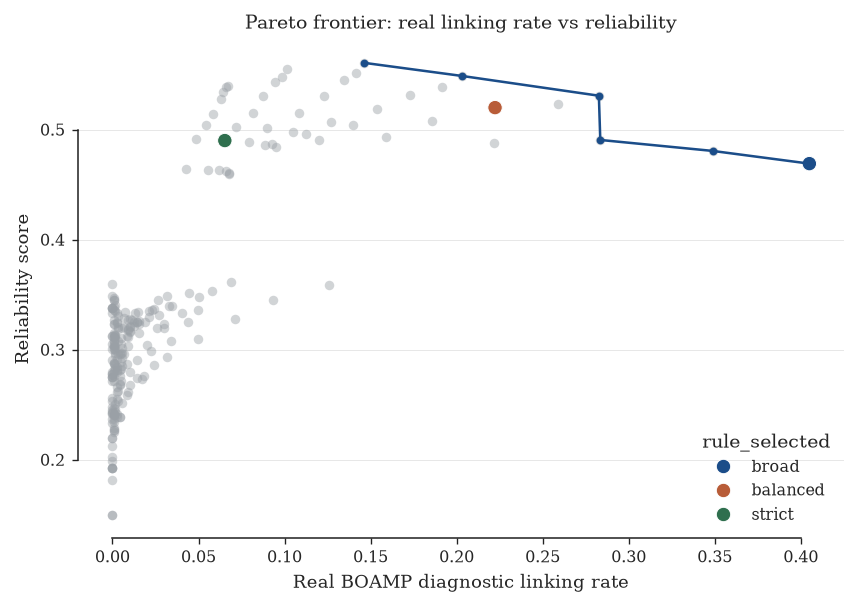

/home/senghakrou/stage-1/reports/figures/validation/parameter_pareto_frontier.png


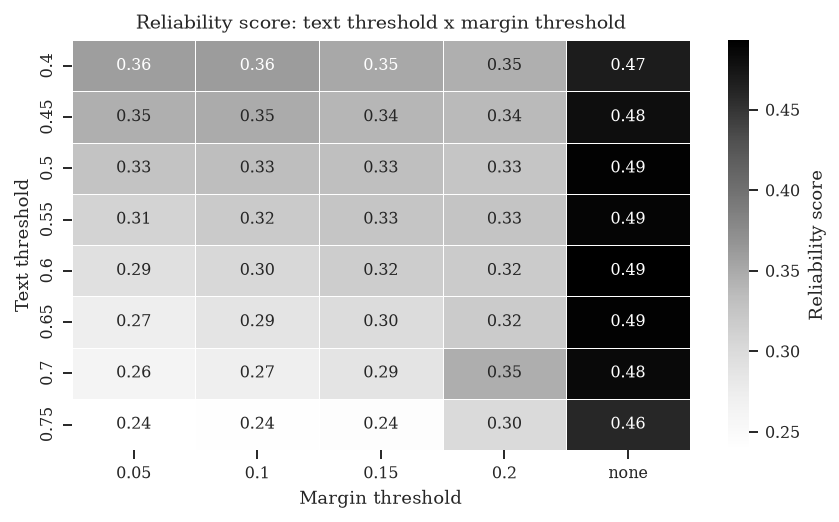

/home/senghakrou/stage-1/reports/figures/validation/parameter_heatmap_text_margin.png


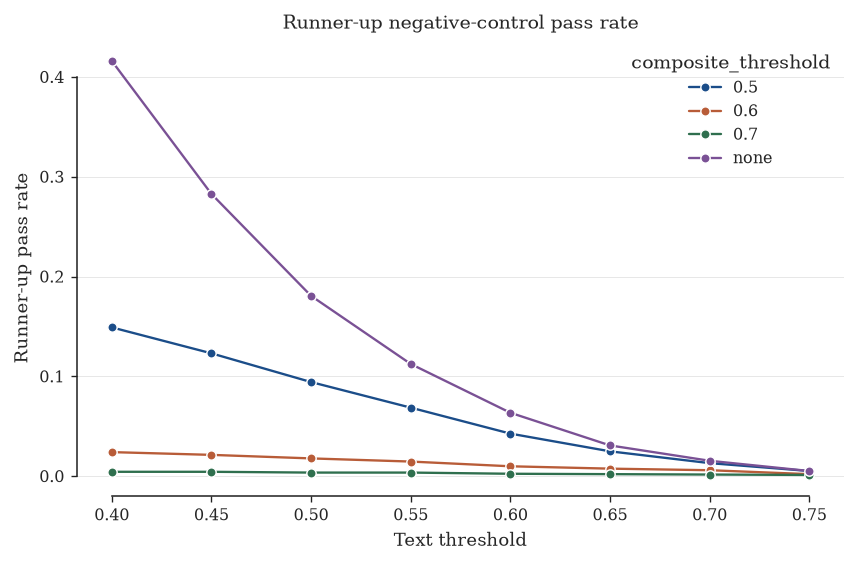

/home/senghakrou/stage-1/reports/figures/validation/parameter_negative_control_pass_rate.png


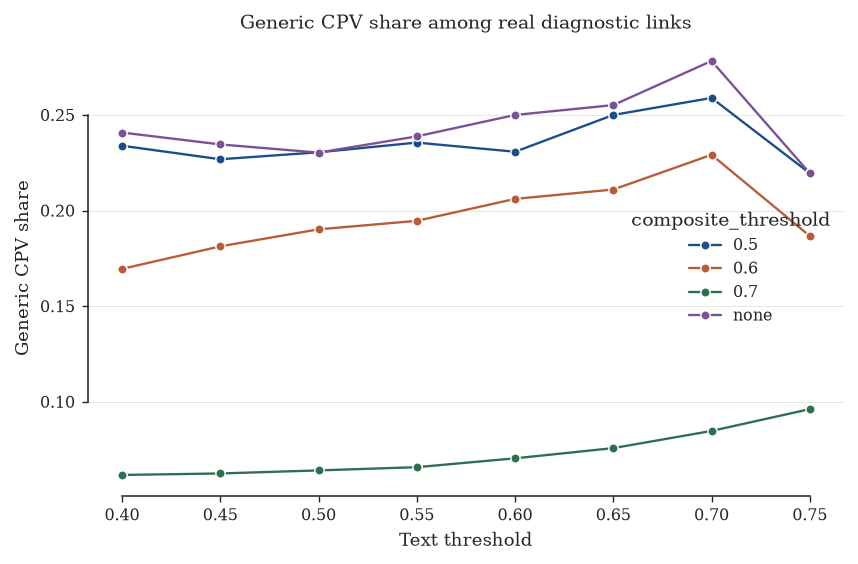

/home/senghakrou/stage-1/reports/figures/validation/parameter_generic_cpv_share.png


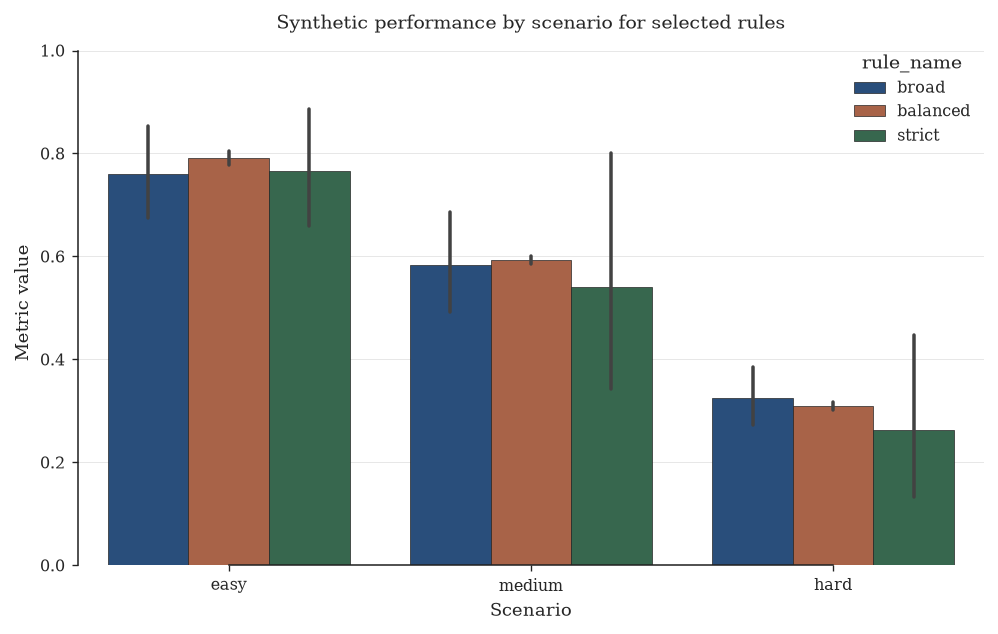

/home/senghakrou/stage-1/reports/figures/validation/parameter_selected_rules_scenario_performance.png


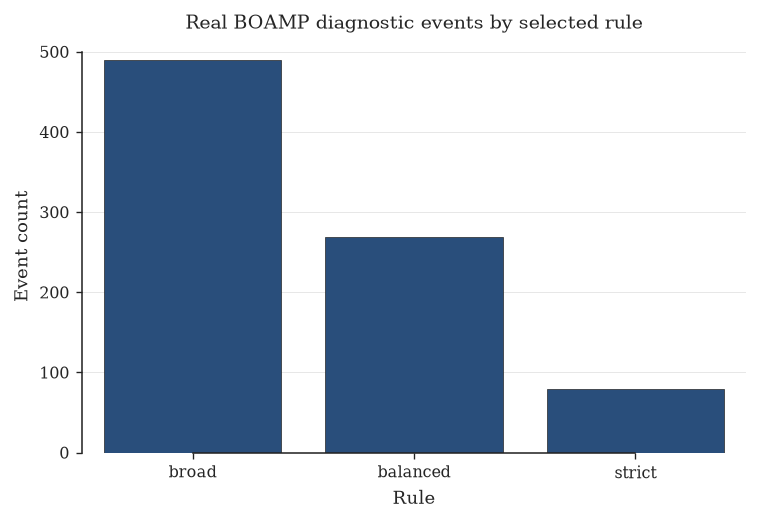

/home/senghakrou/stage-1/reports/figures/validation/parameter_real_event_count_selected_rules.png


In [7]:
def style_axes(ax, grid_axis="y"):
    ax.grid(True, axis=grid_axis, color="#d9d9d9", linewidth=0.45, alpha=0.7)
    ax.grid(False, axis="x" if grid_axis == "y" else "y")
    sns.despine(ax=ax, trim=True)
    ax.tick_params(axis="both", which="major", length=3, width=0.7, color="#222222")
    return ax

def savefig(name: str):
    fig = plt.gcf()
    for ax in fig.axes:
        has_quadmesh = any(type(coll).__name__ == "QuadMesh" for coll in ax.collections)
        if not has_quadmesh:
            style_axes(ax)
    path = REPORT_FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(path)

plot_df = calibration[calibration["generic_cpv_rule"].eq("generic_corrected")].copy()
plot_df["rule_selected"] = "other"
for _, r in recommended.iterrows():
    mask = (
        plot_df["text_threshold"].eq(r["text_threshold"]) &
        plot_df["composite_threshold"].astype(str).eq(str(r["composite_threshold"])) &
        plot_df["margin_threshold"].astype(str).eq(str(r["margin_threshold"])) &
        plot_df["W"].eq(r["W"]) &
        plot_df["generic_cpv_rule"].eq(r["generic_cpv_rule"])
    )
    plot_df.loc[mask, "rule_selected"] = r["rule_name"]

# Precision vs recall by scenario from synthetic grid
synthetic_plot = synthetic_grid[synthetic_grid["generic_cpv_rule"].eq("generic_corrected")].copy()
plt.figure(figsize=(6.2, 4.4))
sns.scatterplot(
    data=synthetic_plot, x="recall", y="precision", hue="scenario", style="W",
    alpha=0.68, s=28, linewidth=0.35, edgecolor="white",
)
plt.title("Synthetic precision-recall trade-off")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1.02); plt.ylim(0, 1.02)
savefig("parameter_precision_vs_recall.png")

# Precision vs real linking rate
plt.figure(figsize=(6.2, 4.4))
sns.scatterplot(
    data=plot_df, x="real_linking_rate", y="medium_hard_precision",
    hue="rule_selected", style="W", alpha=0.72, s=32, linewidth=0.35, edgecolor="white",
)
plt.title("Synthetic precision vs real linking rate")
plt.xlabel("Real BOAMP diagnostic linking rate")
plt.ylabel("Mean precision (medium/hard synthetic)")
savefig("parameter_precision_vs_real_linking_rate.png")

# F1 vs real linking rate
plt.figure(figsize=(6.2, 4.4))
sns.scatterplot(
    data=plot_df, x="real_linking_rate", y="medium_hard_F1",
    hue="rule_selected", style="W", alpha=0.72, s=32, linewidth=0.35, edgecolor="white",
)
plt.title("Synthetic F1 vs real linking rate")
plt.xlabel("Real BOAMP diagnostic linking rate")
plt.ylabel("Mean F1 (medium/hard synthetic)")
savefig("parameter_f1_vs_real_linking_rate.png")

# Pareto frontier on real linking rate vs reliability score for W=6 corrected
pareto_df = current_real_pool.copy().sort_values("real_linking_rate", ascending=False)
pareto_points = []
best_rel = -np.inf
for _, row in pareto_df.iterrows():
    if row["reliability_score"] > best_rel:
        pareto_points.append(row)
        best_rel = row["reliability_score"]
pareto = pd.DataFrame(pareto_points)

plt.figure(figsize=(6.2, 4.4))
sns.scatterplot(
    data=current_real_pool, x="real_linking_rate", y="reliability_score",
    color="#9aa0a6", alpha=0.45, s=24, linewidth=0,
)
plt.plot(pareto["real_linking_rate"], pareto["reliability_score"], color="#1b4d89", linewidth=1.3, marker="o", markersize=3)
sns.scatterplot(
    data=plot_df[plot_df["rule_selected"].isin(["broad", "balanced", "strict"])],
    x="real_linking_rate", y="reliability_score", hue="rule_selected",
    s=55, edgecolor="white", linewidth=0.5,
)
plt.title("Pareto frontier: real linking rate vs reliability")
plt.xlabel("Real BOAMP diagnostic linking rate")
plt.ylabel("Reliability score")
savefig("parameter_pareto_frontier.png")

# Heatmap: text threshold x margin threshold, W=6 corrected and no composite threshold
heat = current_real_pool[current_real_pool["composite_threshold"].astype(str).eq("none")].copy()
heat["margin_label"] = heat["margin_threshold"].astype(str)
heat_pivot = heat.pivot_table(index="text_threshold", columns="margin_label", values="reliability_score", aggfunc="mean")
plt.figure(figsize=(6.2, 3.8))
sns.heatmap(
    heat_pivot, annot=True, fmt=".2f", cmap="Greys", cbar_kws={"label": "Reliability score"},
    linewidths=0.35, linecolor="white", annot_kws={"fontsize": 8},
)
plt.title("Reliability score: text threshold x margin threshold")
plt.xlabel("Margin threshold")
plt.ylabel("Text threshold")
savefig("parameter_heatmap_text_margin.png")

# Negative-control pass rate by text threshold
neg_plot = current_real_pool[current_real_pool["margin_threshold"].astype(str).eq("none")].copy()
neg_plot = neg_plot[neg_plot["composite_threshold"].astype(str).isin(["none", "0.5", "0.6", "0.7"])]
plt.figure(figsize=(6.2, 4.1))
sns.lineplot(
    data=neg_plot, x="text_threshold", y="negative_control_pass_rate",
    hue="composite_threshold", marker="o", linewidth=1.2,
)
plt.title("Runner-up negative-control pass rate")
plt.xlabel("Text threshold")
plt.ylabel("Runner-up pass rate")
savefig("parameter_negative_control_pass_rate.png")

# Generic CPV share by threshold
plt.figure(figsize=(6.2, 4.1))
sns.lineplot(
    data=neg_plot, x="text_threshold", y="real_generic_cpv_share",
    hue="composite_threshold", marker="o", linewidth=1.2,
)
plt.title("Generic CPV share among real diagnostic links")
plt.xlabel("Text threshold")
plt.ylabel("Generic CPV share")
savefig("parameter_generic_cpv_share.png")

# Easy/medium/hard performance comparison for selected rules
perf_rows = []
for _, r in recommended.iterrows():
    for scenario in ["easy", "medium", "hard"]:
        perf_rows.extend([
            {"rule_name": r["rule_name"], "scenario": scenario, "metric": "precision", "value": r[f"{scenario}_precision"]},
            {"rule_name": r["rule_name"], "scenario": scenario, "metric": "recall", "value": r[f"{scenario}_recall"]},
            {"rule_name": r["rule_name"], "scenario": scenario, "metric": "F1", "value": r[f"{scenario}_F1"]},
        ])
perf_plot = pd.DataFrame(perf_rows)
plt.figure(figsize=(7.2, 4.6))
sns.barplot(data=perf_plot, x="scenario", y="value", hue="rule_name", edgecolor="#222222", linewidth=0.35)
plt.title("Synthetic performance by scenario for selected rules")
plt.xlabel("Scenario")
plt.ylabel("Metric value")
plt.ylim(0, 1.02)
savefig("parameter_selected_rules_scenario_performance.png")

# Real event count under selected rules
plt.figure(figsize=(5.5, 3.8))
sns.barplot(data=recommended, x="rule_name", y="real_event_count", edgecolor="#222222", linewidth=0.35)
plt.title("Real BOAMP diagnostic events by selected rule")
plt.xlabel("Rule")
plt.ylabel("Event count")
savefig("parameter_real_event_count_selected_rules.png")


## 7. Negative-Control Context

The calibration table uses runner-up candidates as the rule-level negative control. Existing placebo summaries from the robustness notebook are displayed below when available.


In [8]:
if not placebo_summary.empty:
    display(placebo_summary)
else:
    print("No placebo summary file found.")

manual_metrics = loaded.get("manual_validation_metrics", pd.DataFrame())
if not manual_metrics.empty:
    display(manual_metrics.head(12))


,group,n,mean_composite_score,median_composite_score,std_composite_score,pct_score_gte_070,pct_score_gte_050
0,real_links,665,0.5545,0.5293,0.1436,14.9,60.2
1,runner_up,2536,0.4280,0.4196,0.0906,0.7,19.8
2,synthetic_no_buyer,665,0.4012,0.3719,0.1437,4.8,20.9


,metric,value
0,audit_date,2026-07-02
1,auditor,"AI-assisted manual review (Claude, full official BOAMP records + corpus-wide counter-search)"
2,sample_size,150
3,linked_audited,100
4,unlinked_audited,50
5,TP,14
6,FP,82
7,UNCERTAIN_linked,4
8,TN,41
9,FN,6


## 8. Final Verification


In [9]:
expected_outputs = [
    REPORT_TABLES / "parameter_calibration_results.csv",
    REPORT_TABLES / "recommended_event_rules.csv",
]
expected_figures = [
    "parameter_precision_vs_recall.png",
    "parameter_precision_vs_real_linking_rate.png",
    "parameter_f1_vs_real_linking_rate.png",
    "parameter_pareto_frontier.png",
    "parameter_heatmap_text_margin.png",
    "parameter_negative_control_pass_rate.png",
    "parameter_generic_cpv_share.png",
    "parameter_selected_rules_scenario_performance.png",
    "parameter_real_event_count_selected_rules.png",
]

verification_rows = []
for path in expected_outputs:
    verification_rows.append({"check": f"output exists: {path.relative_to(PROJ)}", "status": "PASS" if path.exists() else "FAIL"})
for fig in expected_figures:
    path = REPORT_FIGURES / fig
    verification_rows.append({"check": f"figure exists: {path.relative_to(PROJ)}", "status": "PASS" if path.exists() else "FAIL"})

reloaded_results = pd.read_csv(REPORT_TABLES / "parameter_calibration_results.csv")
reloaded_rules = pd.read_csv(REPORT_TABLES / "recommended_event_rules.csv")
verification_rows.append({
    "check": "calibration table contains actual computed rows",
    "status": "PASS" if len(reloaded_results) == len(calibration) and len(reloaded_results) > 0 else "FAIL",
})
verification_rows.append({
    "check": "recommended rules table has broad/balanced/strict",
    "status": "PASS" if set(reloaded_rules["rule_name"]) == {"broad", "balanced", "strict"} else "FAIL",
})
verification_rows.append({
    "check": "real BOAMP reported only as diagnostic/proxy rates",
    "status": "PASS" if "precision" not in [c.lower() for c in reloaded_rules.columns if c.startswith("real_")] else "FAIL",
})

notebook_text = NOTEBOOK_PATH.read_text(errors="ignore") if NOTEBOOK_PATH.exists() else ""
blocked_phrases = [
    "verified legal " + "renewal",
    "proven real " + "precision",
    "ground truth " + "precision on real",
    "real legal " + "ground truth",
]
violations = [phrase for phrase in blocked_phrases if phrase.lower() in notebook_text.lower()]
verification_rows.append({
    "check": "no real-data overclaiming language",
    "status": "PASS" if not violations else "FAIL",
    "detail": ",".join(violations),
})

final_verification = pd.DataFrame(verification_rows)
final_verification.to_csv(REPORT_TABLES / "parameter_calibration_verification.csv", index=False)
display(final_verification)

if (final_verification["status"] != "PASS").any():
    raise SystemExit("Final verification failed. See parameter_calibration_verification.csv.")
print("FINAL STATUS: PASS")


,check,status,detail
0,output exists: reports/tables/validation/parameter_calibration_results.csv,PASS,NaN
1,output exists: reports/tables/validation/recommended_event_rules.csv,PASS,NaN
2,figure exists: reports/figures/validation/parameter_precision_vs_recall.png,PASS,NaN
3,figure exists: reports/figures/validation/parameter_precision_vs_real_linking_rate.png,PASS,NaN
4,figure exists: reports/figures/validation/parameter_f1_vs_real_linking_rate.png,PASS,NaN
5,figure exists: reports/figures/validation/parameter_pareto_frontier.png,PASS,NaN
6,figure exists: reports/figures/validation/parameter_heatmap_text_margin.png,PASS,NaN
7,figure exists: reports/figures/validation/parameter_negative_control_pass_rate.png,PASS,NaN
8,figure exists: reports/figures/validation/parameter_generic_cpv_share.png,PASS,NaN
9,figure exists: reports/figures/validation/parameter_selected_rules_scenario_performance.png,PASS,NaN


FINAL STATUS: PASS


## 9. Final Summary

The cell below is generated from the computed calibration tables so the selected rules and metrics match the saved CSV outputs.


In [10]:
def fmt_thresh(x):
    return "none" if pd.isna(x) or str(x) == "none" else f"{float(x):.2f}"

lines = [
    "## Final Calibration Summary",
    "",
    "Real BOAMP is treated as a proxy recurrence dataset: event labels represent an identifiable reappearance of a similar procurement need under the matching rule, not a certified recurrence chain.",
    "",
    "### Selected Rules",
]
for _, r in recommended.iterrows():
    lines.extend([
        f"- **{r['rule_name'].title()}**: text >= {r['text_threshold']:.2f}, "
        f"composite >= {fmt_thresh(r['composite_threshold'])}, "
        f"margin >= {fmt_thresh(r['margin_threshold'])}, W = {int(r['W'])}, "
        f"CPV rule = {r['generic_cpv_rule']}.",
        f"  Real diagnostics: {int(r['real_event_count'])} events, linking rate {r['real_linking_rate']:.1%}, "
        f"runner-up pass rate {r['negative_control_pass_rate']:.1%}, generic CPV share {r['real_generic_cpv_share']:.1%}.",
        f"  Synthetic medium: precision {r['medium_precision']:.3f}, recall {r['medium_recall']:.3f}, F1 {r['medium_F1']:.3f}. "
        f"Synthetic hard: precision {r['hard_precision']:.3f}, recall {r['hard_recall']:.3f}, F1 {r['hard_F1']:.3f}.",
    ])

balanced_row = recommended[recommended["rule_name"].eq("balanced")].iloc[0]
lines.extend([
    "",
    "### Balanced Rule Justification",
    f"The balanced rule was selected because it has the highest actual current real BOAMP diagnostic linking rate among W=6 corrected-CPV rules satisfying the configured synthetic reliability and runner-up negative-control constraints. It yields {int(balanced_row['real_event_count'])} real diagnostic events ({balanced_row['real_linking_rate']:.1%}), while keeping medium-scenario precision at {balanced_row['medium_precision']:.3f} and the runner-up pass rate at {balanced_row['negative_control_pass_rate']:.1%}.",
    "",
    "### Limitations",
    "- The real BOAMP candidate table is the current W=6 pool. W=9 and W=12 rows in the calibration results are lower-bound diagnostics unless the real candidate-pair table is regenerated with wider windows.",
    "- Synthetic precision, recall, and F1 validate behavior under controlled simulated noise; they do not measure real BOAMP precision.",
    "- Runner-up candidates are a useful negative control but not manually certified non-links.",
    "",
    "### Next Step",
    "Regenerate the real BOAMP proxy-event dataset using the balanced rule, then rerun the survival modeling notebook with broad, balanced, and strict definitions as sensitivity variants.",
    "",
    "### Final Status",
    "PASS. All expected tables and figures were saved, and verification checks passed.",
])

display(Markdown("\\n".join(lines)))


## Final Calibration Summary\n\nReal BOAMP is treated as a proxy recurrence dataset: event labels represent an identifiable reappearance of a similar procurement need under the matching rule, not a certified recurrence chain.\n\n### Selected Rules\n- **Broad**: text >= 0.40, composite >= none, margin >= none, W = 6, CPV rule = generic_corrected.\n  Real diagnostics: 490 events, linking rate 40.5%, runner-up pass rate 41.6%, generic CPV share 24.1%.\n  Synthetic medium: precision 0.493, recall 0.686, F1 0.574. Synthetic hard: precision 0.273, recall 0.385, F1 0.320.\n- **Balanced**: text >= 0.50, composite >= 0.50, margin >= none, W = 6, CPV rule = generic_corrected.\n  Real diagnostics: 269 events, linking rate 22.2%, runner-up pass rate 9.4%, generic CPV share 23.0%.\n  Synthetic medium: precision 0.601, recall 0.586, F1 0.593. Synthetic hard: precision 0.318, recall 0.302, F1 0.310.\n- **Strict**: text >= 0.70, composite >= 0.65, margin >= none, W = 6, CPV rule = generic_corrected.\n  Real diagnostics: 79 events, linking rate 6.5%, runner-up pass rate 0.4%, generic CPV share 16.5%.\n  Synthetic medium: precision 0.802, recall 0.342, F1 0.479. Synthetic hard: precision 0.447, recall 0.133, F1 0.205.\n\n### Balanced Rule Justification\nThe balanced rule was selected because it has the highest actual current real BOAMP diagnostic linking rate among W=6 corrected-CPV rules satisfying the configured synthetic reliability and runner-up negative-control constraints. It yields 269 real diagnostic events (22.2%), while keeping medium-scenario precision at 0.601 and the runner-up pass rate at 9.4%.\n\n### Limitations\n- The real BOAMP candidate table is the current W=6 pool. W=9 and W=12 rows in the calibration results are lower-bound diagnostics unless the real candidate-pair table is regenerated with wider windows.\n- Synthetic precision, recall, and F1 validate behavior under controlled simulated noise; they do not measure real BOAMP precision.\n- Runner-up candidates are a useful negative control but not manually certified non-links.\n\n### Next Step\nRegenerate the real BOAMP proxy-event dataset using the balanced rule, then rerun the survival modeling notebook with broad, balanced, and strict definitions as sensitivity variants.\n\n### Final Status\nPASS. All expected tables and figures were saved, and verification checks passed.